In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [4]:
from importlib.metadata import version
print(version("jupyterlab-widgets"))

1.1.1


In [5]:
rgb = cv2.imread("./output_videos/color_png/camera_944122072139_camera_color_image_raw_compressed/000889.png")
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

depth = cv2.imread("./output_videos/depth_png/camera_944122072139_camera_depth_image_rect_raw_compressedDepth/000889.png", cv2.IMREAD_UNCHANGED)

print(rgb.shape)
print(depth.shape)

(720, 1280, 3)
(480, 848)


In [6]:
model = YOLO("yolo11m-seg.pt")


0: 384x640 12 cows, 288.1ms
Speed: 1.6ms preprocess, 288.1ms inference, 4.9ms postprocess per image at shape (1, 3, 384, 640)
cow 0.896500289440155
cow 0.8827258348464966
cow 0.8323766589164734
cow 0.6801323294639587
cow 0.6706543564796448
cow 0.5772523283958435
cow 0.5051992535591125
cow 0.49238190054893494
cow 0.44080400466918945
cow 0.41417211294174194
cow 0.40854528546333313
cow 0.3529699146747589


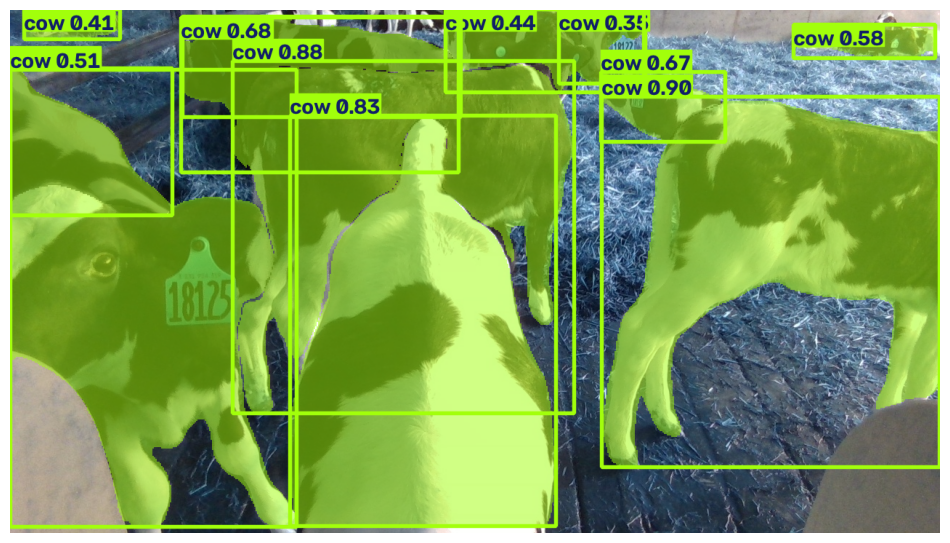

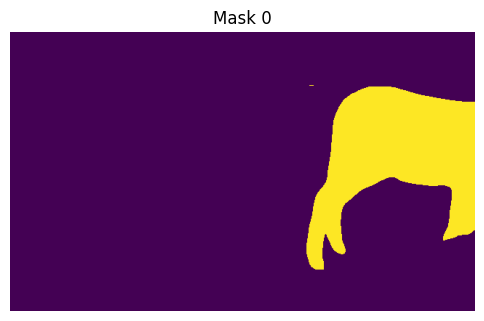

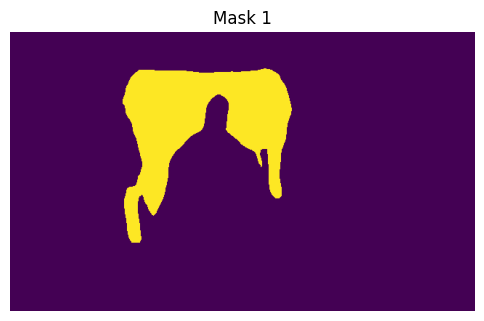

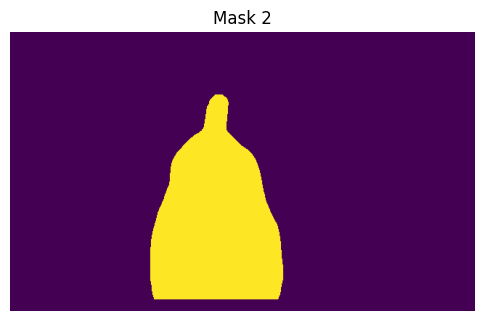

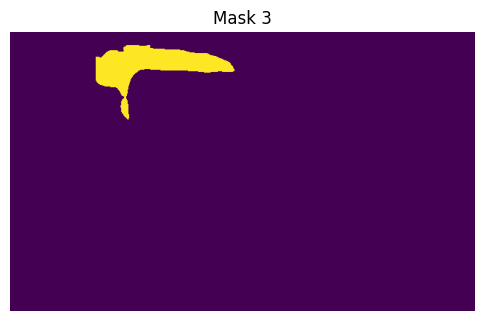

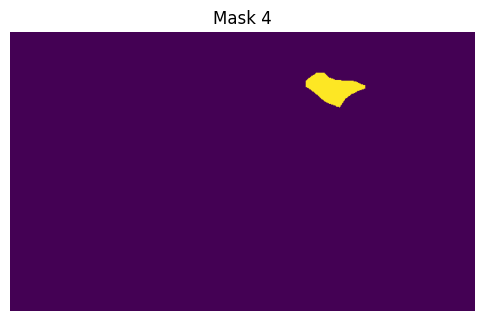

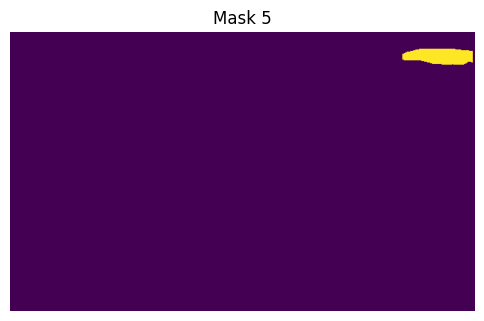

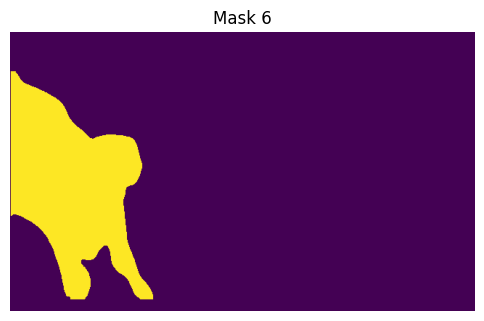

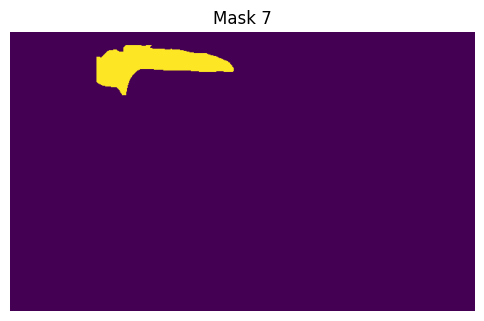

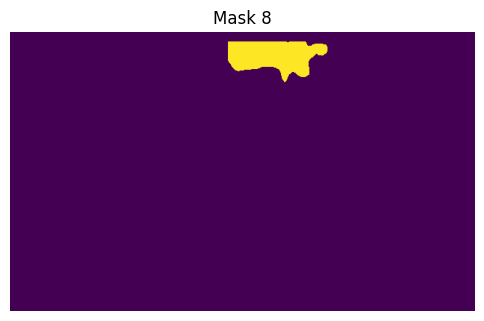

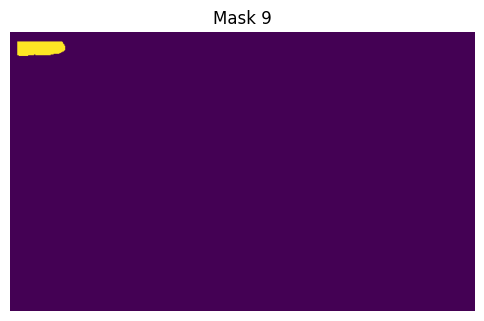

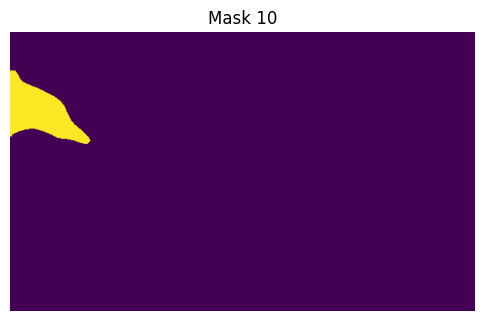

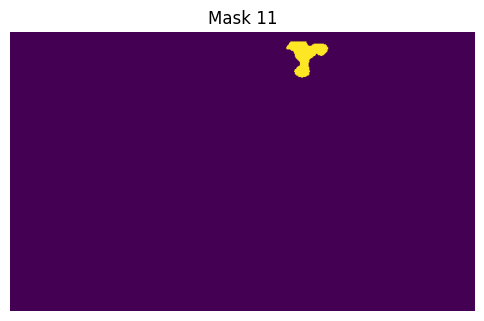

In [7]:
results = model(rgb)
result = results[0]
annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
for box in result.boxes:
    cls = int(box.cls)
    conf = float(box.conf)

    print(model.names[cls], conf)
cow_masks = []
for box, mask in zip(result.boxes, result.masks.data):

    cls = int(box.cls)

    if model.names[cls] == "cow":
        cow_masks.append(mask)

for i, mask in enumerate(cow_masks):

    plt.figure(figsize=(6,6))
    plt.imshow(mask.cpu().numpy())
    plt.title(f"Mask {i}")
    plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(383.5), np.float64(-0.5))

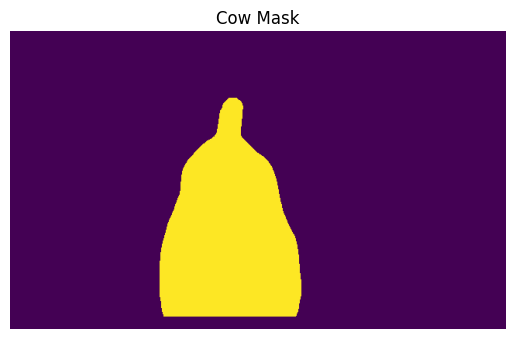

In [8]:
cow_mask = result.masks.data[2, ...]
plt.imshow(cow_mask)
plt.title("Cow Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

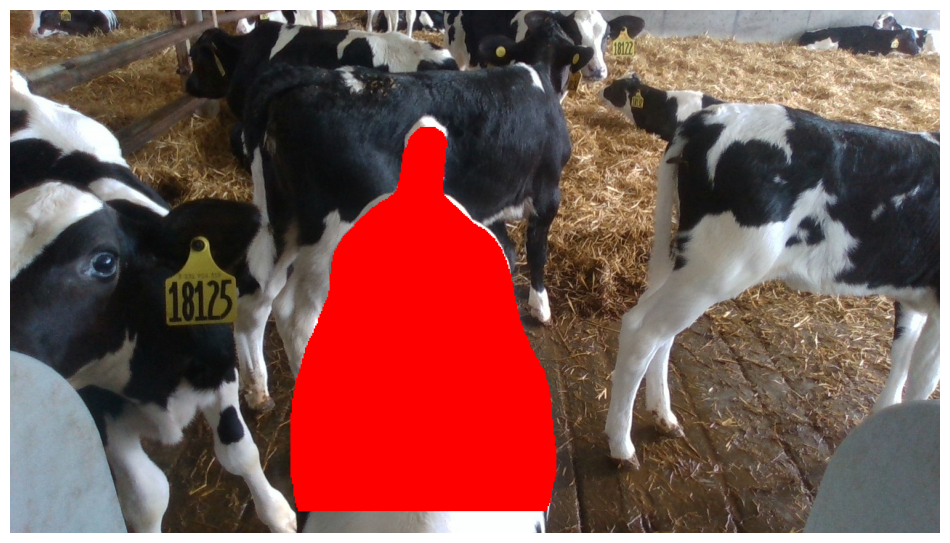

In [9]:
overlay = rgb.copy()
cow_mask = cv2.resize(
    cow_mask.cpu().numpy().astype(np.uint8),
    (rgb.shape[1], rgb.shape[0]),  # (width, height)
    interpolation=cv2.INTER_NEAREST
).astype(bool)
overlay[cow_mask > 0] = [255, 0, 0]

plt.figure(figsize=(12,8))
plt.imshow(overlay)
plt.axis("off")

(np.float64(-0.5), np.float64(847.5), np.float64(479.5), np.float64(-0.5))

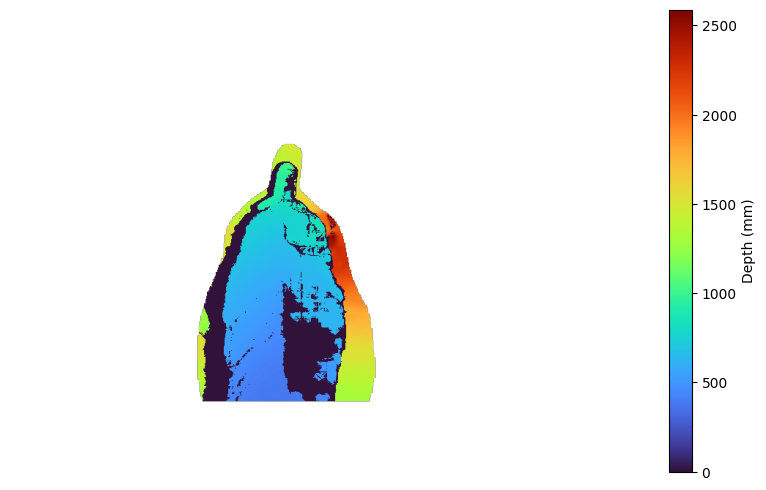

In [10]:
from torch import is_tensor
if is_tensor(cow_mask):
    cow_mask.cpu().numpy()
cow_mask = cv2.resize(
    cow_mask.astype(np.uint8),
    (depth.shape[1], depth.shape[0]),
    interpolation=cv2.INTER_NEAREST
)
cow_depth = depth.copy()
cow_depth = depth.astype(np.float32)
cow_depth[cow_mask == 0] = np.nan

plt.figure(figsize=(10,6))

plt.imshow(
    cow_depth,
    cmap="turbo",
    vmin=np.nanmin(cow_depth),
    vmax=np.nanmax(cow_depth)
)

plt.colorbar(label="Depth (mm)")
plt.axis("off")

My guess is that the mask is  slightly off because I forgot to record the rectified color / depth streams. Would also explain different size of depth / rgb tensors.

In [11]:
mask_area = np.count_nonzero(cow_mask)

print(mask_area)

58335


In [12]:
import bag_video
from rclpy.serialization import deserialize_message
from sensor_msgs.msg import CameraInfo
reader = bag_video.make_reader("./realsense_data_20260721_143907")
color_intrinsics = None
depth_intrinsics = None
while reader.has_next():
    topic, data, timestamp = reader.read_next()
    if "color/camera_info" in topic and color_intrinsics is None:
        msg = deserialize_message(data, CameraInfo)
        color_intrinsics = msg.k
        print(color_intrinsics)
        found_color = True
    if "depth/camera_info" in topic and depth_intrinsics is None:
        msg = deserialize_message(data, CameraInfo)
        depth_intrinsics = msg.k
        print(depth_intrinsics)
        found_depth = True


[INFO] [1785264402.348806371] [rosbag2_storage]: Opened database './realsense_data_20260721_143907/realsense_data_20260721_143907_0.db3' for READ_ONLY.


[     423.72           0      422.38           0      423.72      236.58           0           0           1]
[     904.72           0      654.73           0      902.92       368.5           0           0           1]


In [22]:
fx = depth_intrinsics[0]
fy = depth_intrinsics[4]
cx = depth_intrinsics[2]
cy = depth_intrinsics[5]
ys, xs = np.where(cow_mask)

points = []
for y, x in zip(ys, xs):

    z = cow_depth[y, x] / 1000.0

    if z == 0:
        continue

    X = (x - cx) * z / fx
    Y = (y - cy) * z / fy

    points.append([X, Y, z])

points = np.array(points)

print(points.shape)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [20]:
import open3d as o3d
from open3d.web_visualizer import draw

# 1. Create PointCloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: Estimate normals for better lighting/shading
pcd.estimate_normals()

# 2. Render directly using Open3D Web Visualizer
draw(pcd)

[Open3D INFO] Window window_3 created.


WebVisualizer(window_uid='window_3')

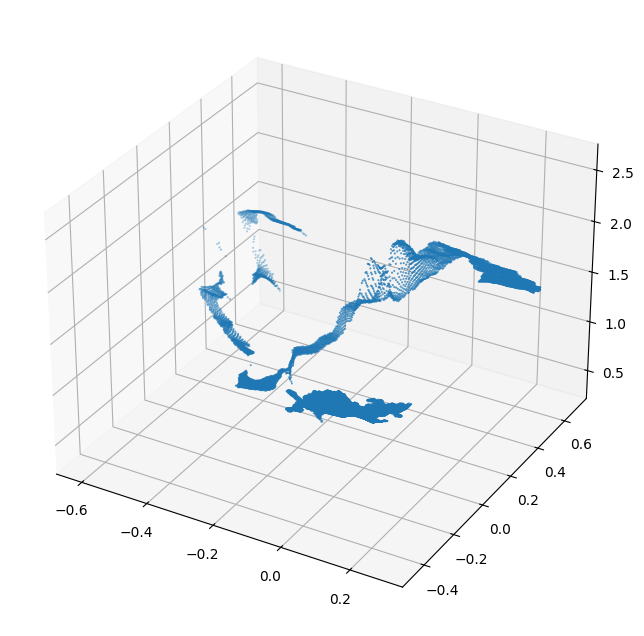

In [23]:
import matplotlib.pyplot as plt
import numpy as np

pts = np.asarray(pcd.points)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pts[:,0],
    pts[:,1],
    pts[:,2],
    s=0.2
)

plt.show()

Dimensions (m): [     2.1885      1.2096     0.86823]


In [25]:
length = np.percentile(points[:,0], 99) - np.percentile(points[:,0], 1)
height = np.percentile(points[:,1], 99) - np.percentile(points[:,1], 1)
width  = np.percentile(points[:,2], 99) - np.percentile(points[:,2], 1)
print(length)
print(height)
print(width)

0.8080099127725693
1.0512375358025101
1.900000125169754
